In [2]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import pycountry
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot 
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
!pip install chart_studio
import chart_studio.plotly as py
import cufflinks
cufflinks.go_offline()
cufflinks.set_config_file(world_readable=True, theme='pearl')

#Geographical Plotting
import folium
from folium import Choropleth, Circle, Marker
from folium import plugins
from folium.plugins import HeatMap, MarkerCluster


import bar_chart_race as bcr
from IPython.display import HTML


plt.rcParams['figure.figsize'] = 8, 5
plt.style.use("fivethirtyeight")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings('ignore')

In [4]:
city_day = pd.read_csv('city_day.csv')
cities_db = pd.read_csv('Indian Cities Database.csv')

In [6]:
display("CITY DAILY DATA")
display(city_day.head(5))

'CITY DAILY DATA'

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,01-01-2019,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,02-01-2019,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,03-01-2019,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,04-01-2019,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,05-01-2019,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [8]:
city_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [10]:
def missing_values_table(df):

        mis_val = df.isnull().sum()
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        return mis_val_table_ren_columns

missing_values= missing_values_table(city_day)
missing_values.style.background_gradient(cmap='Reds')

Your selected dataframe has 16 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
Xylene,18109,61.300000
PM10,11140,37.700000
NH3,10328,35.000000
Toluene,8041,27.200000
Benzene,5623,19.000000
AQI,4681,15.900000
AQI_Bucket,4681,15.900000
PM2.5,4598,15.600000
NOx,4185,14.200000
O3,4022,13.600000


In [12]:
cities = city_day['City'].value_counts()
print(f'Total number of cities in the dataset : {len(cities)}')
print(cities.index)

Total number of cities in the dataset : 26
Index(['Ahmedabad', 'Delhi', 'Mumbai', 'Bengaluru', 'Lucknow', 'Chennai',
       'Hyderabad', 'Patna', 'Gurugram', 'Visakhapatnam', 'Amritsar',
       'Jorapokhar', 'Jaipur', 'Thiruvananthapuram', 'Amaravati',
       'Brajrajnagar', 'Talcher', 'Kolkata', 'Guwahati', 'Coimbatore',
       'Shillong', 'Chandigarh', 'Bhopal', 'Ernakulam', 'Kochi', 'Aizawl'],
      dtype='object', name='City')


In [14]:
city_day['Date'] = pd.to_datetime(city_day['Date'], format='%d-%m-%Y')

In [16]:
print(f"The available data is between {city_day['Date'].min()} and {city_day['Date'].max()}")

The available data is between 2019-01-01 00:00:00 and 2024-07-01 00:00:00


In [18]:
city_day['BTX'] = city_day['Benzene']+city_day['Toluene']+city_day['Xylene']
city_day.drop(['Benzene','Toluene','Xylene'],axis=1);

In [20]:
city_day['Particulate_Matter'] = city_day['PM2.5']+city_day['PM10']

In [22]:
pollutants = ['PM2.5','PM10','NO2', 'CO', 'SO2','O3', 'BTX']

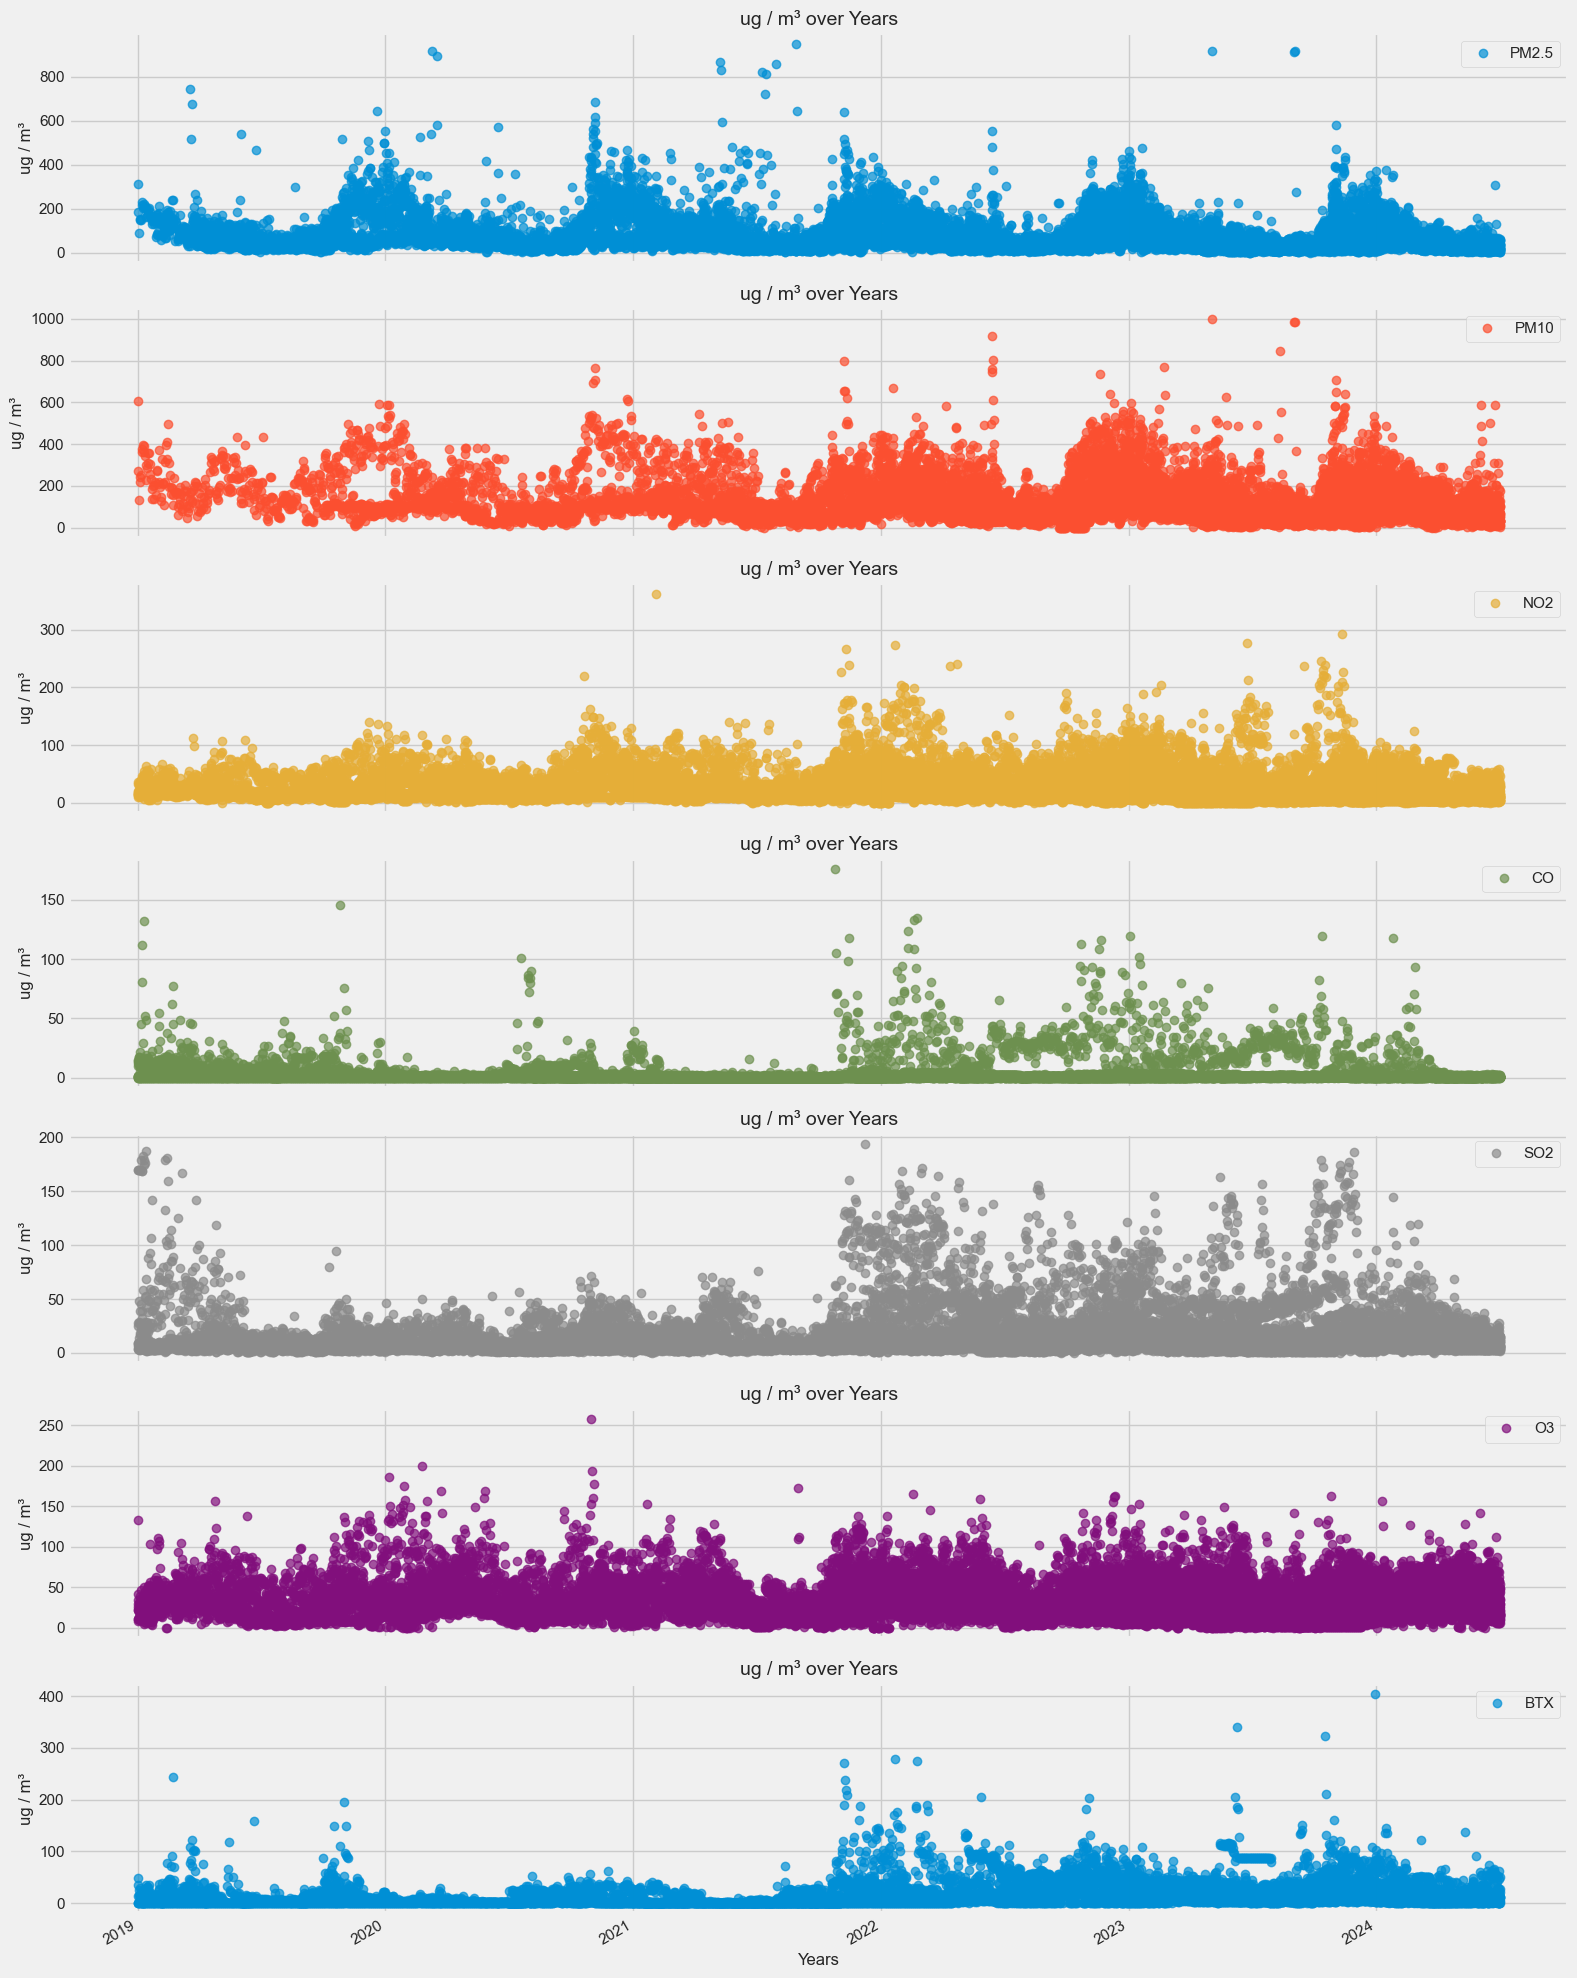

In [24]:
city_day.set_index('Date', inplace=True)

axes = city_day[pollutants].plot(marker='o', alpha=0.7, linestyle='None', figsize=(16, 20), subplots=True)

for ax in axes:
    ax.set_xlabel('Years', fontsize=12)
    ax.set_ylabel('ug / m³', fontsize=12)
    ax.grid(True)
    ax.set_title(f"{ax.get_ylabel()} over Years", fontsize=14)

plt.tight_layout()
plt.show()

In [26]:
def trend_plot(dataframe,value):

    df['year'] = [d.year for d in df.Date]
    df['month'] = [d.strftime('%b') for d in df.Date]
    years = df['year'].unique()

    fig, axes = plt.subplots(1, 2, figsize=(14,6), dpi= 80)
    sns.boxplot(x='year', y=value, data=df, ax=axes[0])
    sns.pointplot(x='month', y=value, data=df.loc[~df.year.isin([2015, 2020]), :])

    axes[0].set_title('Year-wise Box Plot \n(The Trend)', fontsize=18); 
    axes[1].set_title('Month-wise Plot \n(The Seasonality)', fontsize=18)
    plt.show()


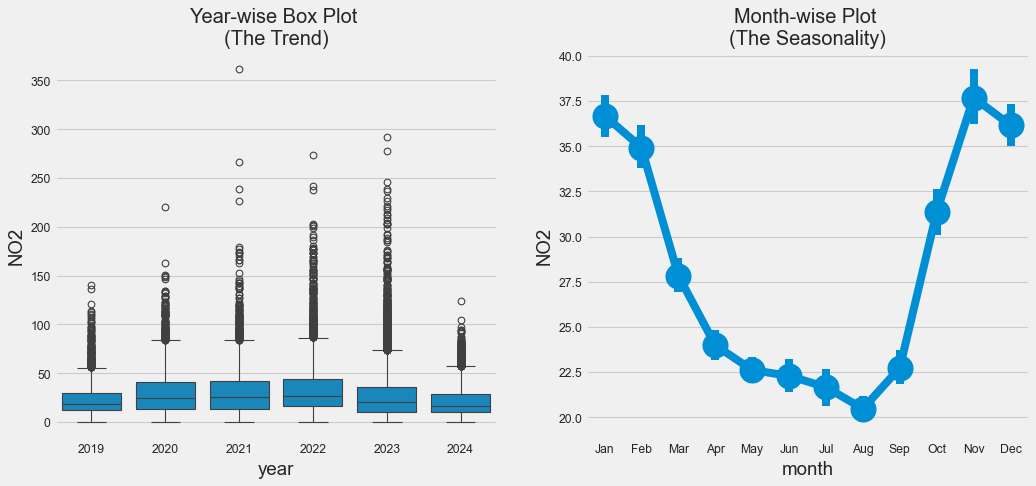

In [28]:
city_day.reset_index(inplace=True)
df = city_day.copy()
value='NO2'
trend_plot(df,value)

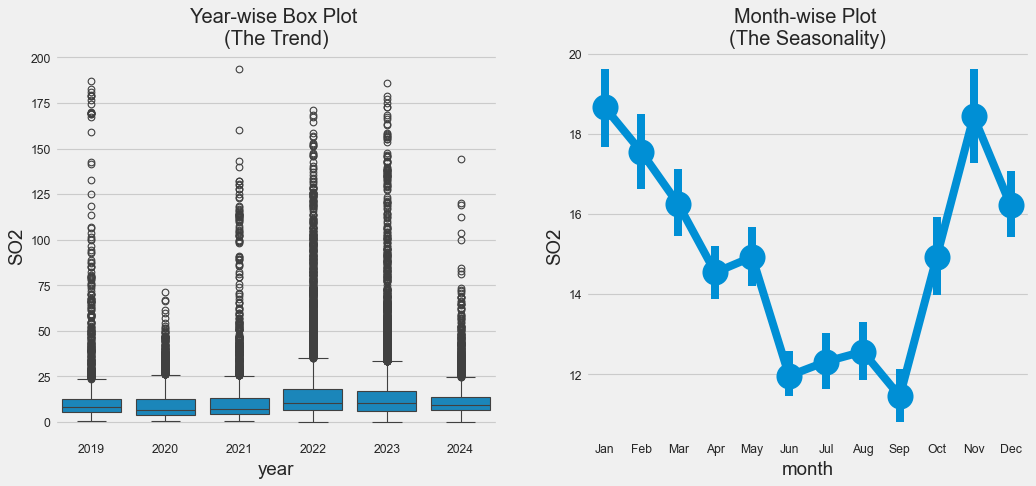

In [30]:
df = city_day.copy()
value='SO2'
trend_plot(df,value)

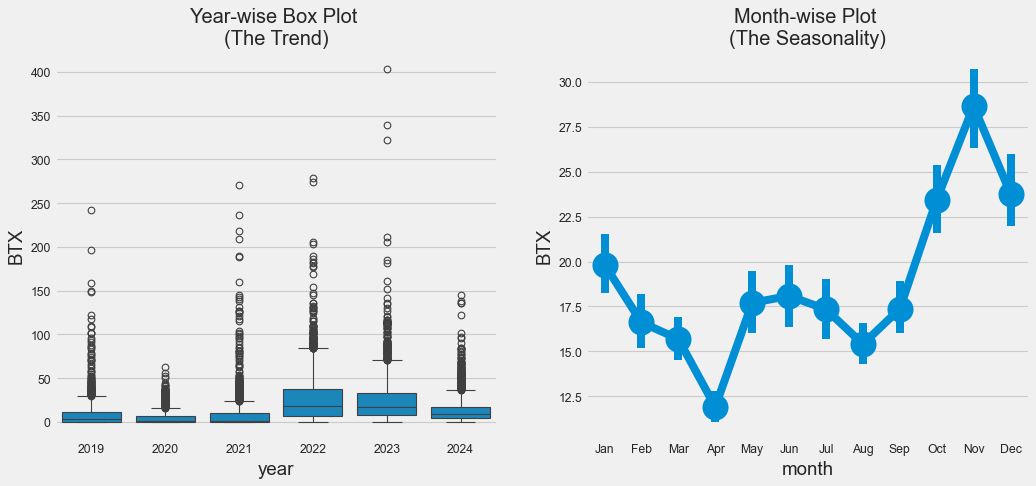

In [32]:
value='BTX'
trend_plot(df,value)

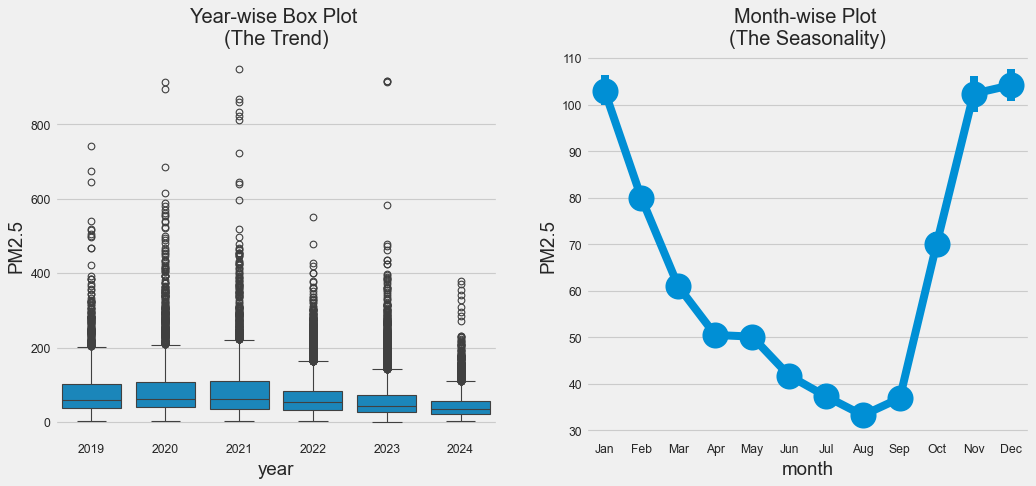

In [34]:
value='PM2.5'
trend_plot(df,value)

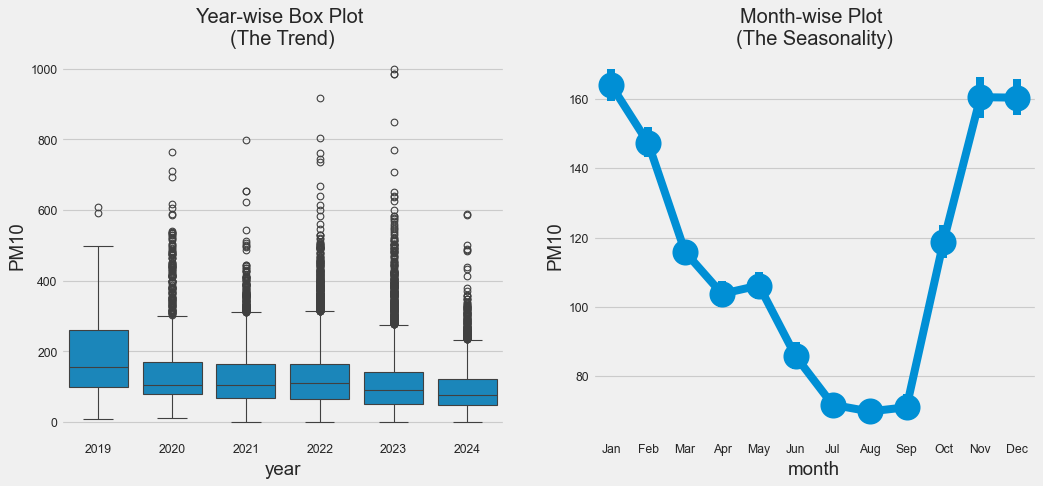

In [36]:
value='PM10'
trend_plot(df,value)

In [38]:
from IPython.display import display, HTML

def display_side_by_side(*args):
    html_str = ''
    for df in args:
        html_str += df.to_html()  # Convert each Styler object to HTML
    display(HTML(html_str.replace('table', 'table style="display:inline"')))

In [40]:
def max_polluted_city(pollutant):
    x1 = city_day[[pollutant, 'City']].groupby(["City"]).mean().sort_values(by=pollutant, ascending=False).reset_index()
    x1[pollutant] = round(x1[pollutant], 2)
    return x1.style.background_gradient(cmap='OrRd')


In [42]:
pm2_5 = max_polluted_city('PM2.5')
pm10 = max_polluted_city('PM10')
no2 = max_polluted_city('NO2')
so2 = max_polluted_city('SO2')
co = max_polluted_city('CO')
btx = max_polluted_city('BTX')

display_side_by_side(pm2_5, pm10, no2, so2, co, btx)

,City,PM2.5
0,Patna,123.500000
1,Delhi,117.200000
2,Gurugram,117.100000
3,Lucknow,109.710000
4,Ahmedabad,67.850000
5,Kolkata,64.360000
6,Jorapokhar,64.230000
7,Brajrajnagar,64.060000
8,Guwahati,63.690000
9,Talcher,61.410000


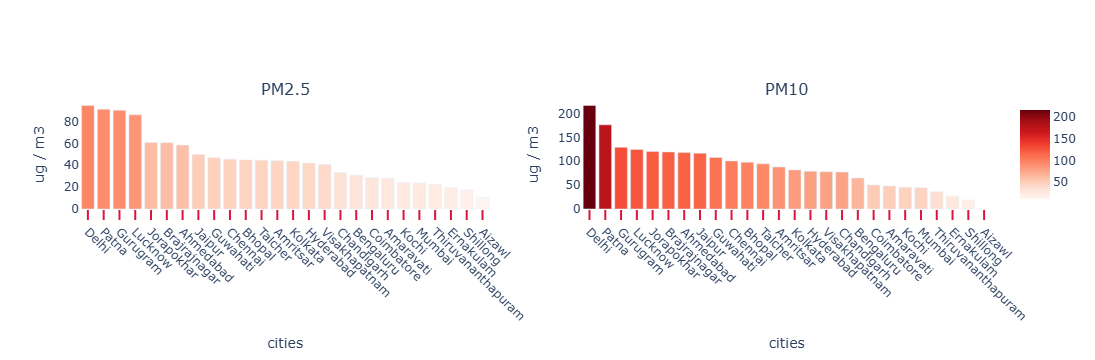

In [44]:
x2= city_day[['PM2.5','City']].groupby(["City"]).median().sort_values(by='PM2.5',ascending=False).reset_index()
x3 = city_day[['PM10','City']].groupby(["City"]).median().sort_values(by='PM10',ascending=False).reset_index()

from plotly.subplots import make_subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("PM2.5","PM10"))

fig.add_trace(go.Bar( y=x2['PM2.5'], x=x2["City"],  
                     marker=dict(color=x2['PM2.5'], coloraxis="coloraxis")),
              1, 1)


fig.add_trace(go.Bar( y=x3['PM10'], x=x2["City"],  
                     marker=dict(color=x3['PM10'], coloraxis="coloraxis")),
              1, 2)
fig.update_layout(coloraxis=dict(colorscale='reds'), showlegend=False,plot_bgcolor='white')
fig.update_xaxes(ticks="outside", tickwidth=2,tickangle=45, tickcolor='crimson', ticklen=10,title_text="cities")
fig.update_yaxes(title_text="ug / m3", row=1, col=1)
fig.update_yaxes(title_text="ug / m3", row=1, col=2)
fig.show()

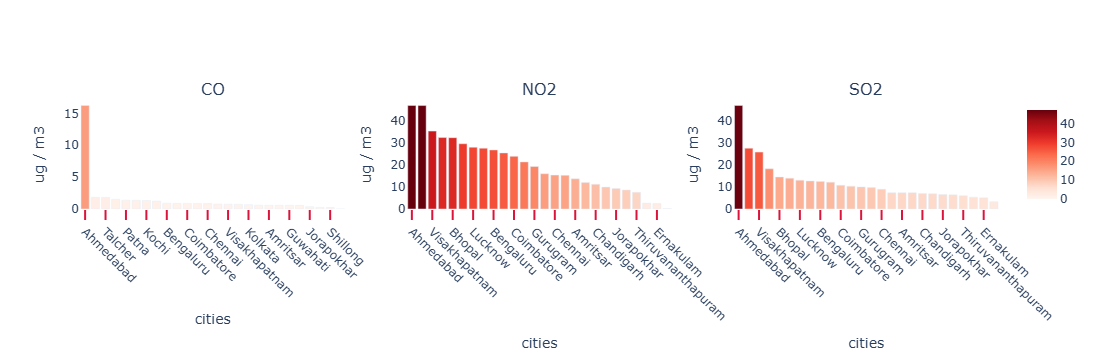

In [46]:
x4= city_day[['CO','City']].groupby(["City"]).median().sort_values(by='CO',ascending=False).reset_index()
x5 = city_day[['NO2','City']].groupby(["City"]).median().sort_values(by='NO2',ascending=False).reset_index()
x6 = city_day[['SO2','City']].groupby(["City"]).median().sort_values(by='SO2',ascending=False).reset_index()


from plotly.subplots import make_subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("CO","NO2",'SO2'))

fig.add_trace(go.Bar( y=x4['CO'], x=x4["City"],  
                     marker=dict(color=x4['CO'], coloraxis="coloraxis")),
              1, 1)


fig.add_trace(go.Bar( y=x5['NO2'], x=x5["City"],  
                     marker=dict(color=x5['NO2'], coloraxis="coloraxis")),
              1, 2)

fig.add_trace(go.Bar( y=x6['SO2'], x=x5["City"],  
                     marker=dict(color=x6['SO2'], coloraxis="coloraxis")),
              1, 3)
fig.update_layout(coloraxis=dict(colorscale='reds'), showlegend=False,plot_bgcolor='white')
fig.update_xaxes(ticks="outside", tickwidth=2,tickangle=45, tickcolor='crimson', ticklen=10,title_text="cities")
fig.update_yaxes(title_text="ug / m3", row=1, col=1)
fig.update_yaxes(title_text="ug / m3", row=1, col=2)
fig.update_yaxes(title_text="ug / m3", row=1, col=3)
fig.show()

In [48]:
cities = ['Ahmedabad','Delhi','Bengaluru','Mumbai','Hyderabad','Chennai']

filtered_city_day = city_day[city_day['Date'] >= '2023-01-01']
AQI = filtered_city_day[filtered_city_day.City.isin(cities)][['Date','City','AQI','AQI_Bucket']]
AQI.head()

,Date,City,AQI,AQI_Bucket
1461,2023-01-01,Ahmedabad,1474.0,Severe
1462,2023-01-02,Ahmedabad,1246.0,Severe
1463,2023-01-03,Ahmedabad,1719.0,Severe
1464,2023-01-04,Ahmedabad,1264.0,Severe
1465,2023-01-05,Ahmedabad,1127.0,Severe


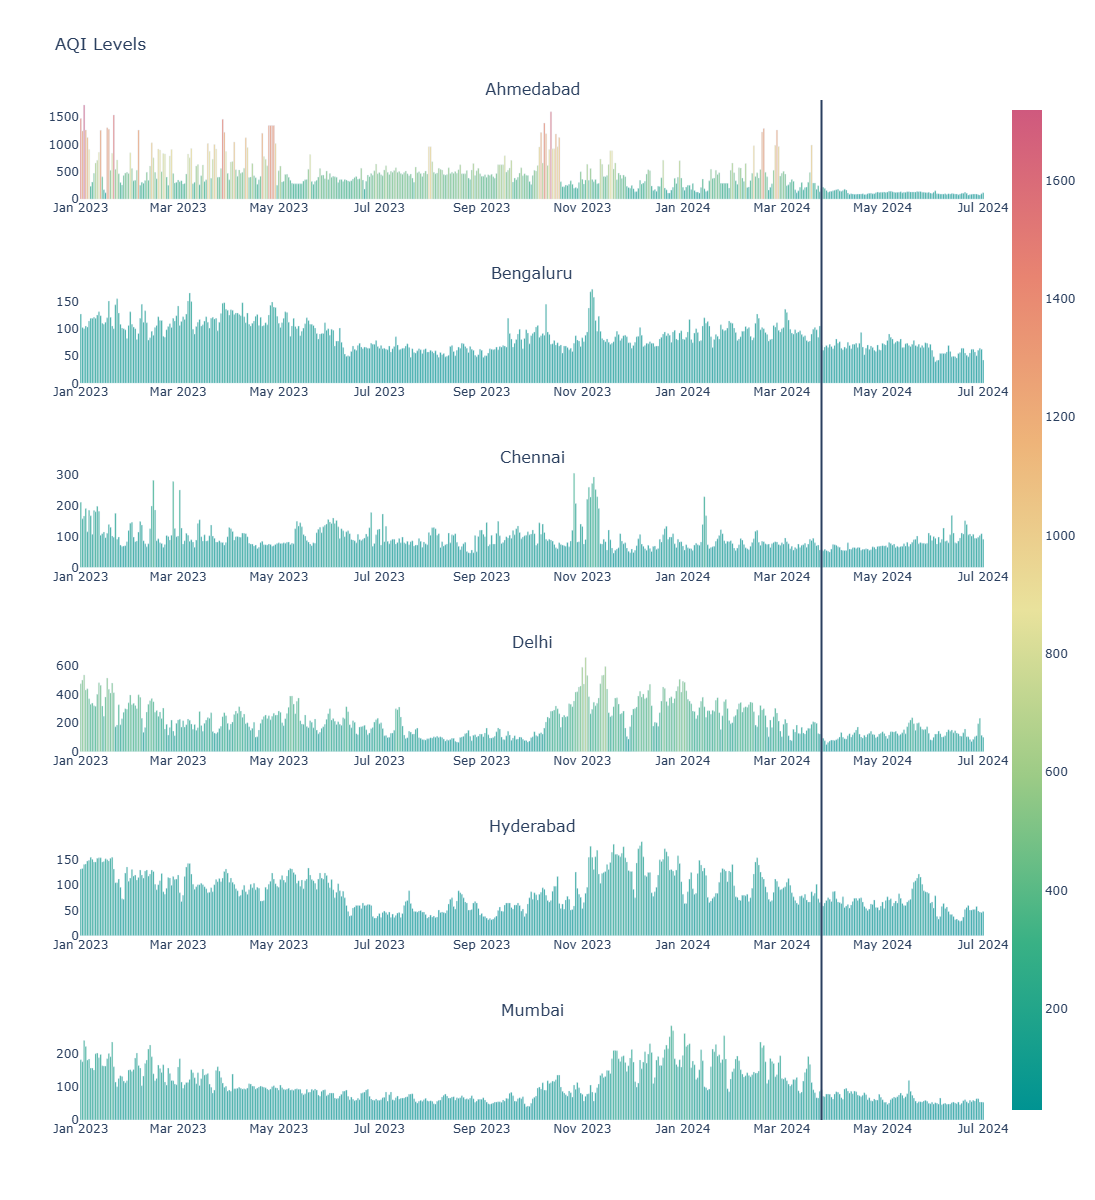

In [50]:
AQI_pivot = AQI.pivot(index='Date', columns='City', values='AQI')
AQI_pivot.fillna(method='bfill',inplace=True)


from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=6, cols=1,
    subplot_titles=("Ahmedabad","Bengaluru","Chennai","Delhi",'Hyderabad','Mumbai'))

fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Ahmedabad'],
                    marker=dict(color=AQI_pivot['Ahmedabad'],coloraxis="coloraxis")),
              1, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Bengaluru'],
                    marker=dict(color=AQI_pivot['Bengaluru'], coloraxis="coloraxis")),
              2, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Chennai'],
                    marker=dict(color=AQI_pivot['Chennai'], coloraxis="coloraxis")),
              3, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Delhi'],
                    marker=dict(color=AQI_pivot['Delhi'], coloraxis="coloraxis")),
              4, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Hyderabad'],
                    marker=dict(color=AQI_pivot['Hyderabad'], coloraxis="coloraxis")),
              5, 1)
fig.add_trace(go.Bar(x=AQI_pivot.index, y=AQI_pivot['Mumbai'],
                    marker=dict(color=AQI_pivot['Mumbai'], coloraxis="coloraxis")),
              6, 1)

fig.update_layout(coloraxis=dict(colorscale='Temps'),showlegend=False,title_text="AQI Levels")

fig.update_layout(plot_bgcolor='white')

fig.update_layout( width=800,height=1200,shapes=[
      dict(
      type= 'line',
      yref= 'paper', y0= 0, y1= 1,
      xref= 'x', x0= '2024-03-25', x1= '2024-03-25'
    )
])

fig.show()

In [52]:
AQI_before2023 = AQI_pivot['2024-01-01':'2024-03-25']
AQI_after2024 = AQI_pivot['2024-03-26':'2024-05-01']

In [54]:
print(AQI_before2023.mean())
print(AQI_after2024.mean())

City
Ahmedabad    383.776471
Bengaluru     96.023529
Chennai       80.317647
Delhi        246.305882
Hyderabad     94.435294
Mumbai       148.776471
dtype: float64
City
Ahmedabad    127.810811
Bengaluru     68.486486
Chennai       62.351351
Delhi        107.270270
Hyderabad     65.567568
Mumbai        73.891892
dtype: float64


In [56]:
from matplotlib.patches import Circle, Wedge, Rectangle

def degree_range(n): 
    start = np.linspace(0,180,n+1, endpoint=True)[0:-1]
    end = np.linspace(0,180,n+1, endpoint=True)[1::]
    mid_points = start + ((end-start)/2.)
    return np.c_[start, end], mid_points

def rot_text(ang): 
    rotation = np.degrees(np.radians(ang) * np.pi / np.pi - np.radians(90))
    return rotation

In [58]:
from matplotlib.patches import Circle, Wedge, Rectangle
def gauge(labels=['GOOD','SATISFACTORY','MODERATE','POOR','VERY POOR','EXTREME'], \
          colors='jet_r', arrow=1, title='', fname=False): 
    
    """
    some sanity checks first
    

"""
    
    N = len(labels)
    
    if arrow > N: 
        raise Exception("\n\nThe category ({}) is greated than \
        the length\nof the labels ({})".format(arrow, N))
 
    
    """
    if colors is a string, we assume it's a matplotlib colormap
    and we discretize in N discrete colors 
    """
    
    if isinstance(colors, str):
        cmap = cm.get_cmap(colors, N)
        cmap = cmap(np.arange(N))
        colors = cmap[::-1,:].tolist()
    if isinstance(colors, list): 
        if len(colors) == N:
            colors = colors[::-1]
        else: 
            raise Exception("\n\nnumber of colors {} not equal \
            to number of categories{}\n".format(len(colors), N))

    """
    begins the plotting
    """
    
    fig, ax = plt.subplots()

    ang_range, mid_points = degree_range(N)

    labels = labels[::-1]
    
    """
    plots the sectors and the arcs
    """
    patches = []
    for ang, c in zip(ang_range, colors): 
        # sectors
        patches.append(Wedge((0.,0.), .4, *ang, facecolor='w', lw=2))
        # arcs
        patches.append(Wedge((0.,0.), .4, *ang, width=0.10, facecolor=c, lw=2, alpha=0.5))
    
    [ax.add_patch(p) for p in patches]

    
    """
    set the labels (e.g. 'LOW','MEDIUM',...)
    """

    for mid, lab in zip(mid_points, labels): 

        ax.text(0.35 * np.cos(np.radians(mid)), 0.35 * np.sin(np.radians(mid)), lab, \
            horizontalalignment='center', verticalalignment='center', fontsize=14, \
            fontweight='bold', rotation = rot_text(mid))

    """
    set the bottom banner and the title
    """
    r = Rectangle((-0.4,-0.1),0.8,0.1, facecolor='w', lw=2)
    ax.add_patch(r)
    
    ax.text(0, -0.05, title, horizontalalignment='center', \
         verticalalignment='center', fontsize=22, fontweight='bold')

    """
    plots the arrow now
    """
    
    pos = mid_points[abs(arrow - N)]
    
    ax.arrow(0, 0, 0.225 * np.cos(np.radians(pos)), 0.225 * np.sin(np.radians(pos)), \
                 width=0.04, head_width=0.09, head_length=0.1, fc='k', ec='k')
    
    ax.add_patch(Circle((0, 0), radius=0.02, facecolor='k'))
    ax.add_patch(Circle((0, 0), radius=0.01, facecolor='w', zorder=11))

    """
    removes frame and ticks, and makes axis equal and tight
    """
    
    ax.set_frame_on(False)
    ax.axes.set_xticks([])
    ax.axes.set_yticks([])
    ax.axis('equal')
    plt.tight_layout()
    if fname:
        fig.savefig(fname, dpi=200)

"Ahmedabad's AQI levels"

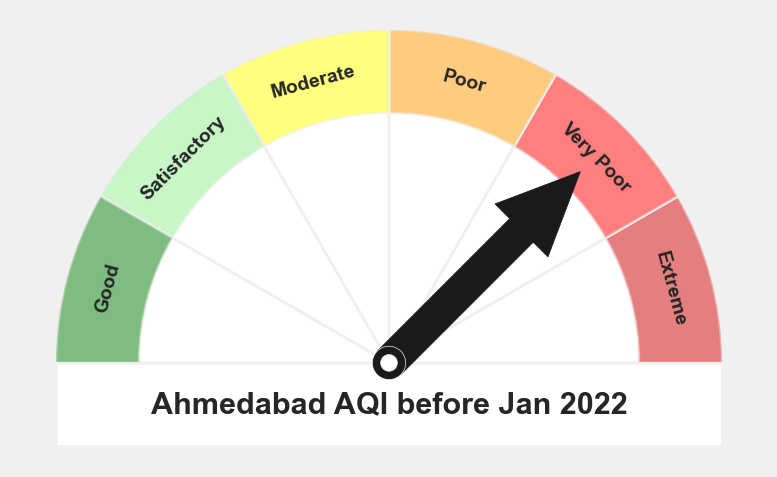

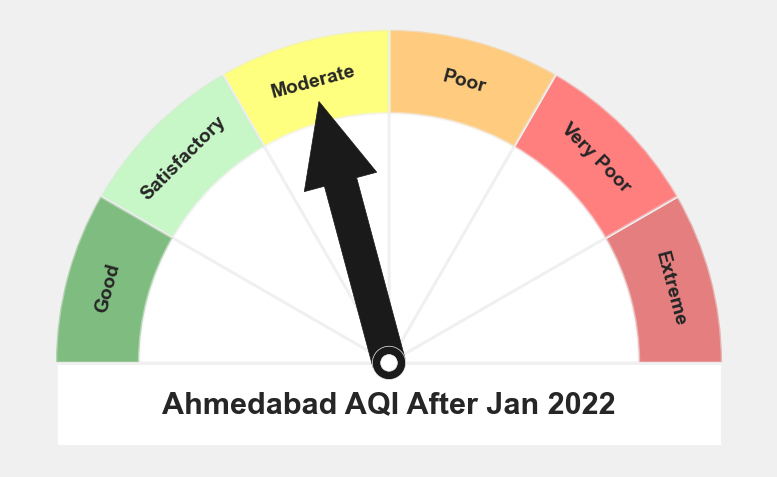

In [60]:
display("Ahmedabad's AQI levels")

gauge(labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Extreme'], \
      colors=['#007A00','#90EE90','#ffff00','#FF9900','#ff0000','#CC0000'], arrow=5, title='Ahmedabad AQI before Jan 2022') 

gauge(labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Extreme'], \
      colors=['#007A00','#90EE90','#ffff00','#FF9900','#ff0000','#CC0000'], arrow=3, title='Ahmedabad AQI After Jan 2022') 

"Delhi's AQI levels"

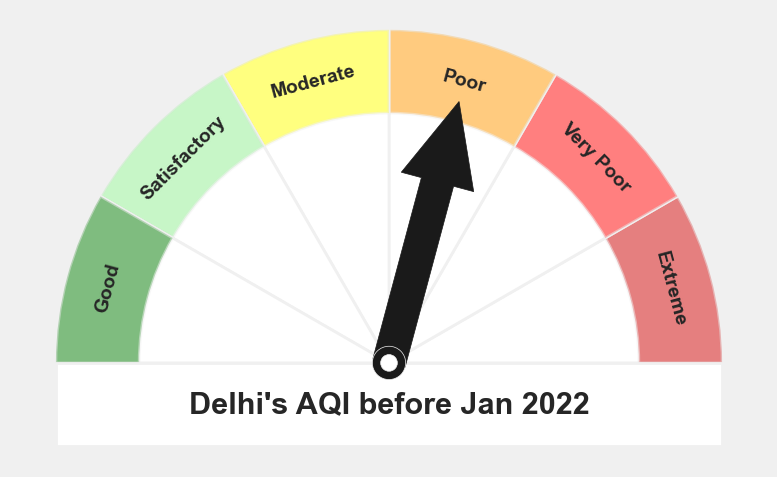

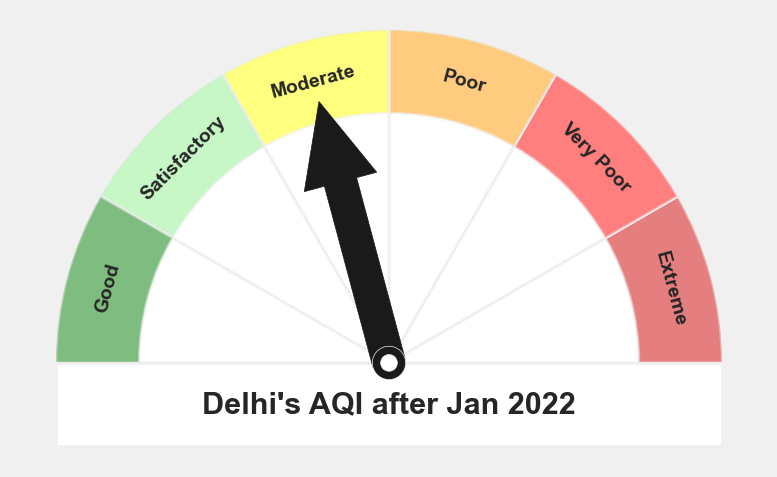

In [62]:
display("Delhi's AQI levels")

gauge(labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Extreme'], \
      colors=['#007A00','#90EE90','#ffff00','#FF9900','#ff0000','#CC0000'], arrow=4, title="Delhi's AQI before Jan 2022") 

gauge(labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Extreme'], \
      colors=['#007A00','#90EE90','#ffff00','#FF9900','#ff0000','#CC0000'], arrow=3, title="Delhi's AQI after Jan 2022") 


"Mumbai's AQI levels"

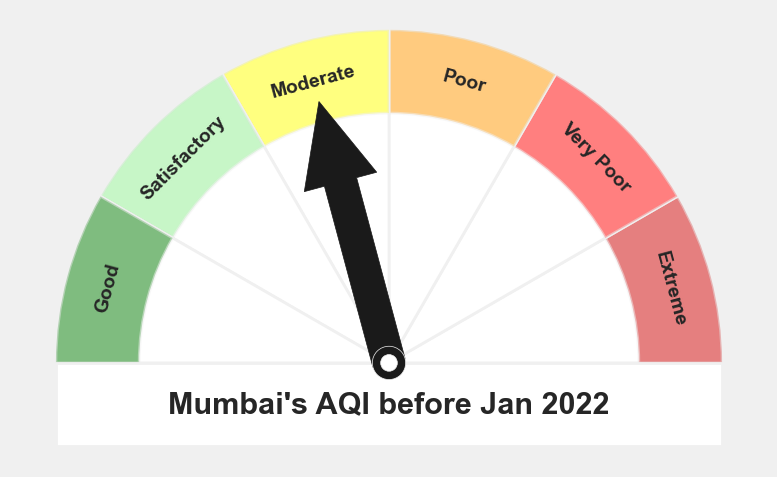

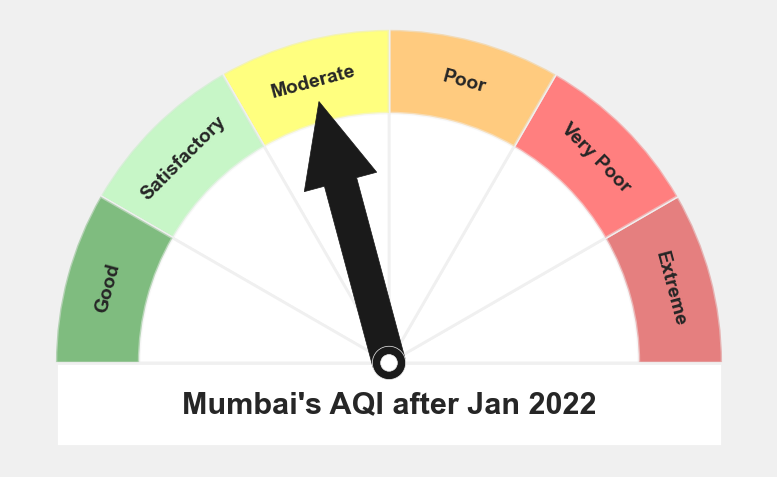

In [64]:
display("Mumbai's AQI levels")

gauge(labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Extreme'], \
      colors=['#007A00','#90EE90','#ffff00','#FF9900','#ff0000','#CC0000'], arrow=3, title="Mumbai's AQI before Jan 2022") 

gauge(labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Extreme'], \
      colors=['#007A00','#90EE90','#ffff00','#FF9900','#ff0000','#CC0000'], arrow=3, title="Mumbai's AQI after Jan 2022") 

In [66]:
start_date1 = '2023-01-01'
end_date1 = '2023-05-01'

mask1 = (city_day['Date'] >= start_date1) & (city_day['Date']  <= end_date1)
pollutants_filtered_2023 = city_day.loc[mask1]
pollutants_filtered_2023.fillna(method='bfill',inplace=True)
pollutants_filtered_2023.set_index('Date',inplace=True);

start_date2 = '2024-01-01'
end_date2 = '2024-05-01'

mask2 = (city_day['Date'] >= start_date2) & (city_day['Date']  <= end_date2)
pollutants_filtered_2024 = city_day.loc[mask2]
pollutants_filtered_2024.fillna(method='bfill',inplace=True)
pollutants_filtered_2024.set_index('Date',inplace=True);


df1 = pollutants_filtered_2023[pollutants_filtered_2023.City.isin(cities)][['City','NO2','SO2','PM2.5','CO']]
df2 = pollutants_filtered_2024[pollutants_filtered_2024.City.isin(cities)][['City','NO2','SO2','PM2.5','CO']]

In [68]:
def pollution_comparison(city):
    """
    Function to plot graph comparing pollutin levels between (Jan-May)2023 and (Jan-May)2024
    
    """
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df1.index, y=df1[df1['City']==city]['NO2'],
                    line=dict(dash='solid',color='green'),name='NO2'))
    fig.add_trace(go.Scatter(x=df1.index, y=df1[df1['City']==city]['SO2'],
                    line=dict(dash='dot',color='red'),name='SO2'))
    fig.add_trace(go.Scatter(x=df1.index, y=df1[df1['City']==city]['PM2.5'],
                    line=dict(dash='dashdot',color='dodgerblue'),name='Particulate_Matter'))
    fig.add_trace(go.Scatter(x=df1.index, y=df1[df1['City']==city]['CO'],
                    line=dict(dash='longdashdot'),mode='lines',name='CO'))
    fig.update_layout(title_text=city+' 2023 ',plot_bgcolor='white')
    fig.update_xaxes(rangeslider_visible=True,zeroline=True,zerolinewidth=1, zerolinecolor='Black')
    fig.show()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df2.index, y=df2[df2['City']==city]['NO2'],
                    line=dict(dash='solid',color='green'),name='NO2'))
    fig.add_trace(go.Scatter(x=df2.index, y=df2[df2['City']==city]['SO2'],
                    line=dict(dash='dot',color='red'),name='SO2'))
    fig.add_trace(go.Scatter(x=df2.index, y=df2[df2['City']==city]['PM2.5'],
                    line=dict(dash='dashdot',color='dodgerblue'),name='Particulate_Matter'))
    fig.add_trace(go.Scatter(x=df2.index, y=df2[df2['City']==city]['CO'],
                    line=dict(dash='longdashdot'),mode='lines',name='CO'))
    fig.update_layout(title_text=city+' 2024 ',plot_bgcolor='white')
    fig.update_xaxes(rangeslider_visible=True,zeroline=True,zerolinewidth=1, zerolinecolor='Black')
    fig.show()

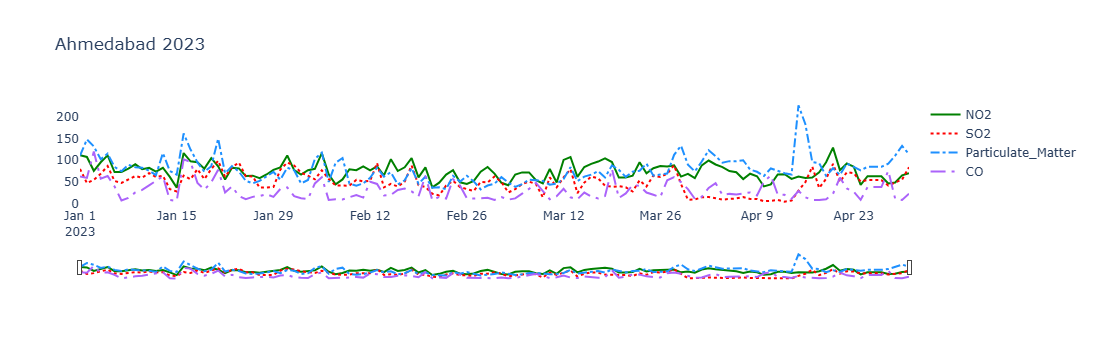

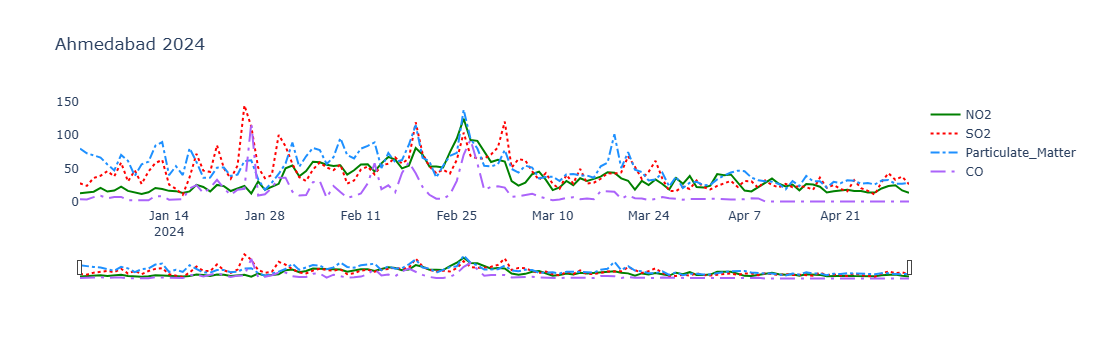

In [70]:
pollution_comparison('Ahmedabad')

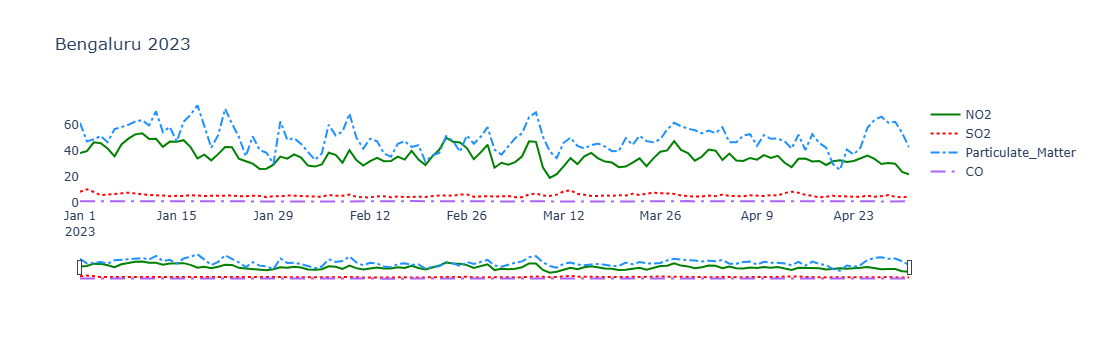

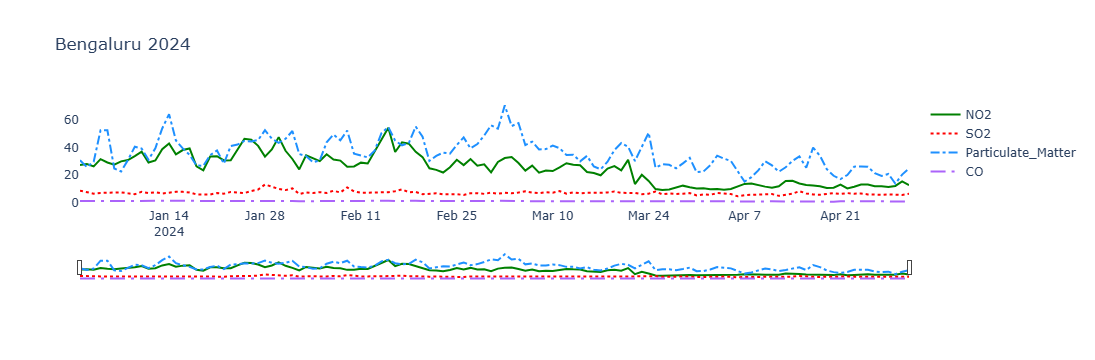

In [72]:
pollution_comparison('Bengaluru')

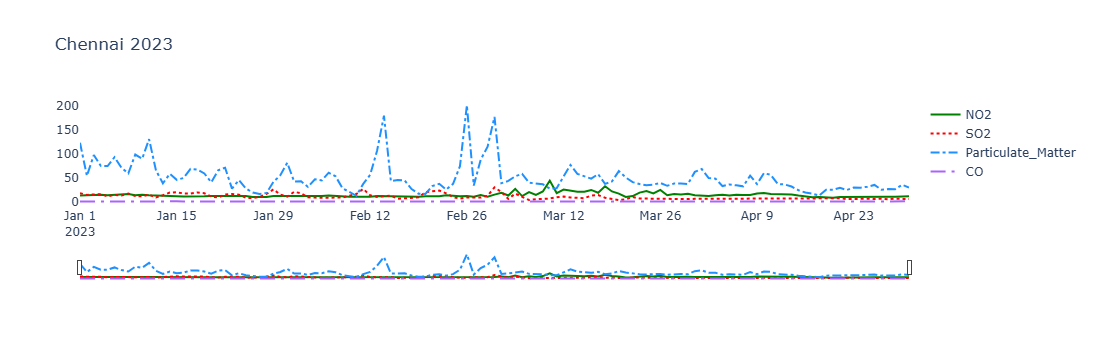

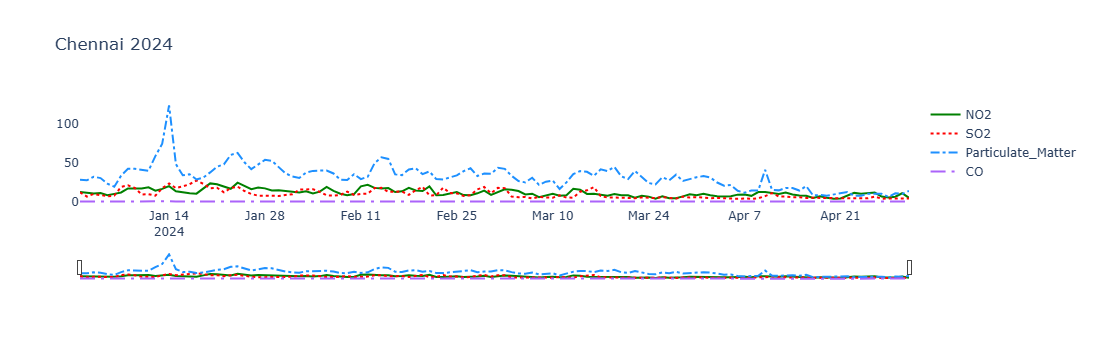

In [74]:
pollution_comparison('Chennai')

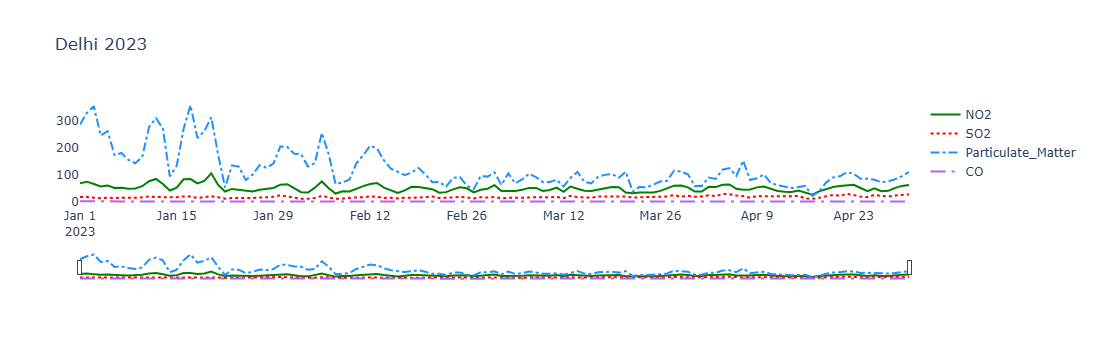

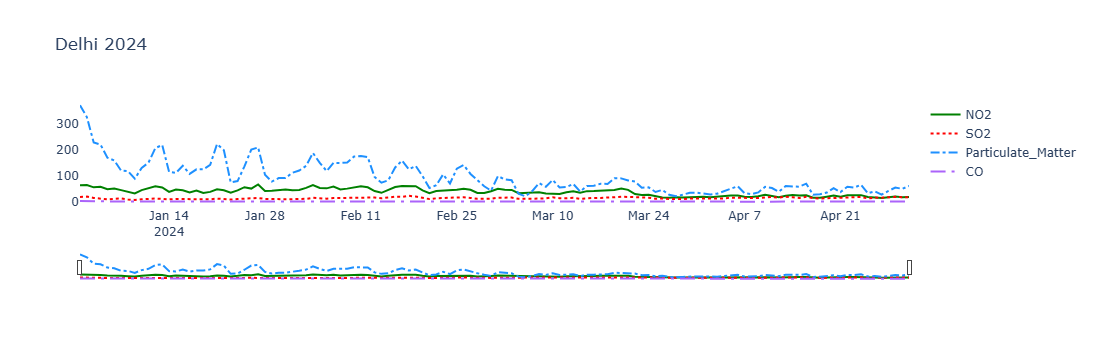

In [76]:
pollution_comparison('Delhi')

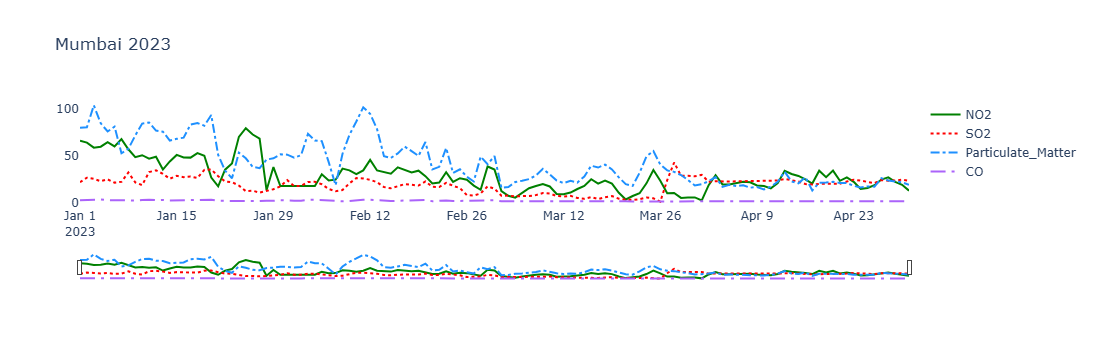

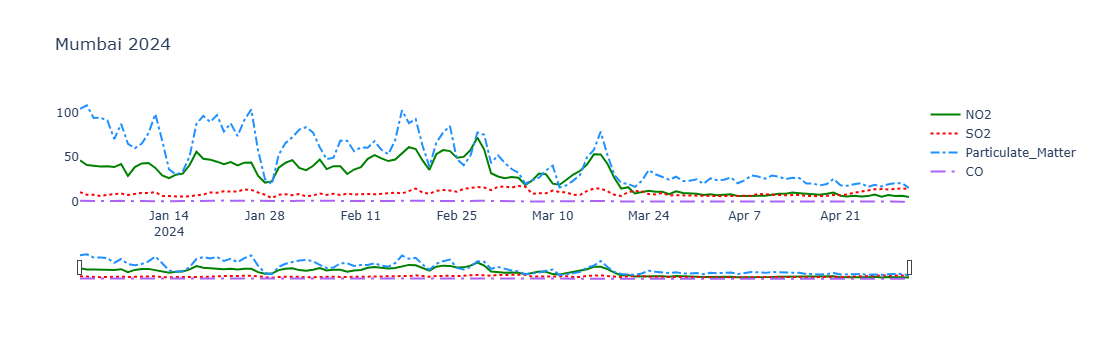

In [78]:
pollution_comparison('Mumbai')

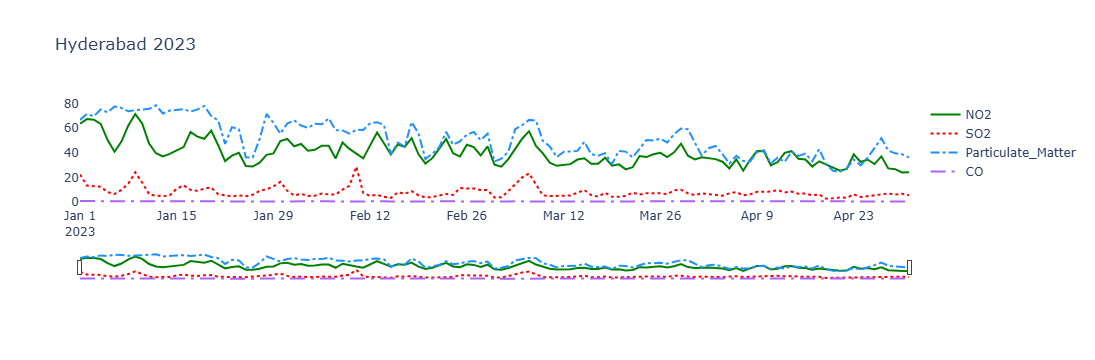

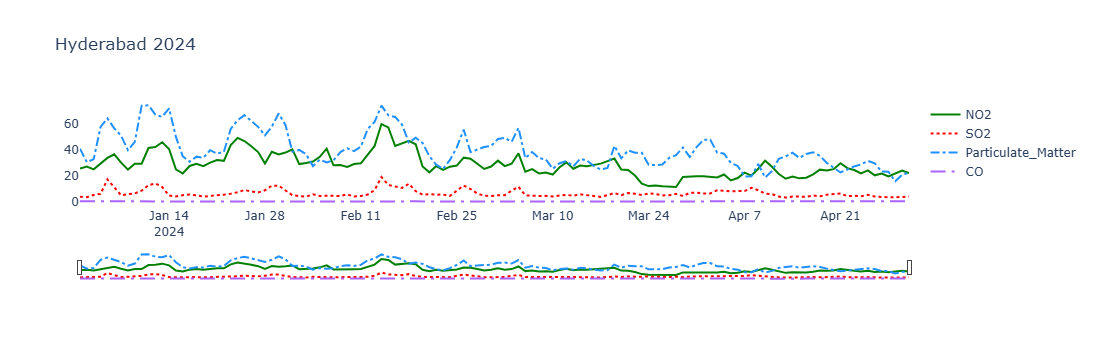

In [80]:
pollution_comparison('Hyderabad')

In [82]:
df11 = pollutants_filtered_2023[['City','AQI']]
df22 = pollutants_filtered_2024[['City','AQI']]

df_2019_coord = df11.groupby('City')['AQI'].mean().to_frame().reset_index()
df_2020_coord = df22.groupby('City')['AQI'].mean().to_frame().reset_index()

df_2019_AQI = pd.merge(df_2019_coord,cities_db,on='City')
df_2019_AQI['AQI'] = df_2019_AQI['AQI'].round(0)
df_2020_AQI = pd.merge(df_2020_coord,cities_db,on='City')
df_2020_AQI['AQI'] = df_2020_AQI['AQI'].round(0)

In [86]:
m = plugins.DualMap(location=(22.9734, 78.6569), tiles=None, zoom_start=5)

folium.TileLayer('Stamen Toner').add_to(m)
folium.TileLayer('openstreetmap').add_to(m)


fg_1 = folium.FeatureGroup(name='2022').add_to(m.m1)
fg_2 = folium.FeatureGroup(name='2024').add_to(m.m2)



for lat, lon, value, name in zip(df_2019_AQI['Lat'], df_2019_AQI['Long'], df_2019_AQI['AQI'], df_2019_AQI['City']):
    folium.CircleMarker([lat, lon],
                        radius=10,
                        icon=folium.Icon(color='red'),
                        popup = ('<strong>City</strong>: ' + str(name).capitalize() + '<br>'
                                '<strong>AQI(Average)</strong>: ' + str(value) + '<br>'),
                        fill_color='red',
                        fill_opacity=0.7 ).add_to(fg_1)





for lat, lon, value, name in zip(df_2020_AQI['Lat'], df_2020_AQI['Long'], df_2020_AQI['AQI'], df_2020_AQI['City']):
    folium.CircleMarker([lat, lon],
                        radius=10,
                        icon=folium.Icon(color='orange'),
                        popup = ('<strong>City</strong>: ' + str(name).capitalize() + '<br>'
                                '<strong>AQI(Average)</strong>: ' + str(value) + '<br>'),
                        fill_color='orange',
                        fill_opacity=0.7 ).add_to(fg_2)


folium.LayerControl(collapsed=False).add_to(m)

m

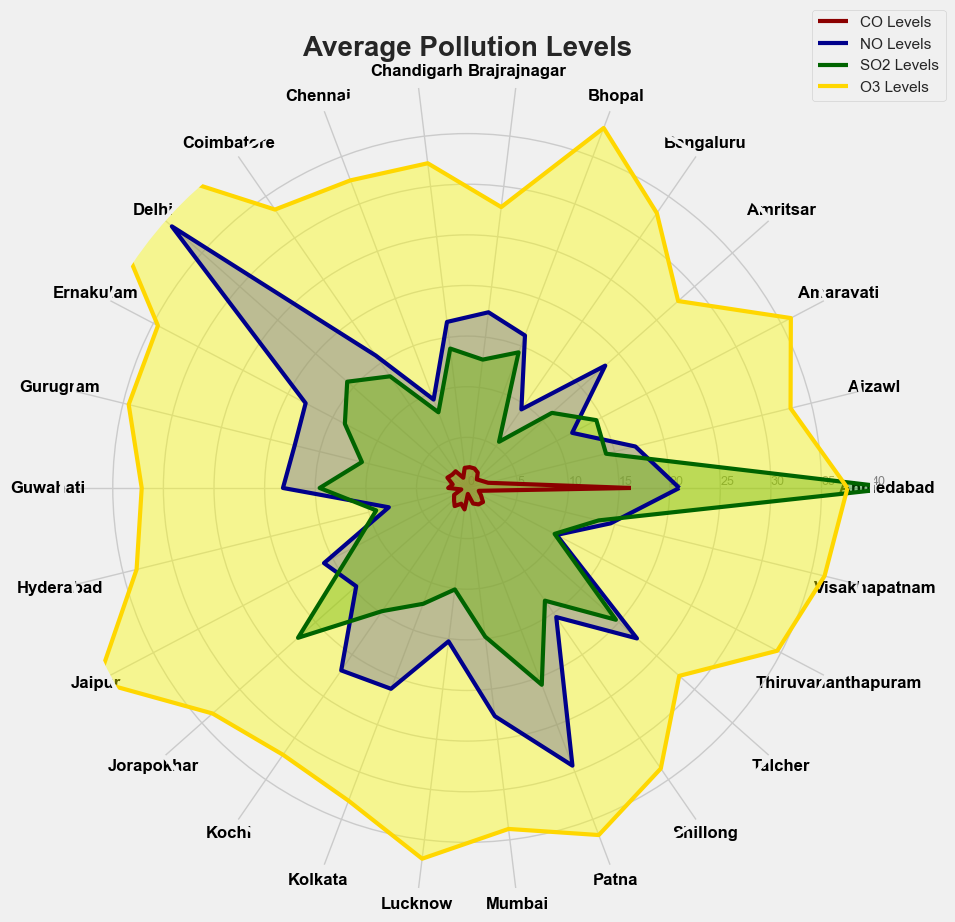

In [88]:


df_CO = city_day.pivot(index='Date', columns='City', values='CO').fillna(city_day['CO'].mean())
df_NO = city_day.pivot(index='Date', columns='City', values='NO').fillna(city_day['NO'].mean())
df_SO2 = city_day.pivot(index='Date', columns='City', values='SO2').fillna(city_day['SO2'].mean())
df_O3 = city_day.pivot(index='Date', columns='City', values='O3').fillna(city_day['O3'].mean())

categories = list(df_CO.columns)
N = len(categories)

values_co  = df_CO.mean().values.flatten()
values_no  = df_NO.mean().values.flatten()
values_so2 = df_SO2.mean().values.flatten()
values_o3  = df_O3.mean().values.flatten()


angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))


ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='black', size=12, fontweight='bold')


ax.set_rlabel_position(0)
ticks = np.linspace(0, 40, 9)  # More granular ticks
ax.set_yticks(ticks)
ax.set_yticklabels([str(int(x)) for x in ticks], color="grey", size=9)
ax.set_ylim(0,40)

ax.plot(angles, np.append(values_co, values_co[0]), linewidth=3, linestyle='solid', label='CO Levels', color='darkred')
ax.fill(angles, np.append(values_co, values_co[0]), color='red', alpha=0.4)

ax.plot(angles, np.append(values_no, values_no[0]), linewidth=3, linestyle='solid', label='NO Levels', color='darkblue')
ax.fill(angles, np.append(values_no, values_no[0]), color='blue', alpha=0.4)

ax.plot(angles, np.append(values_so2, values_so2[0]), linewidth=3, linestyle='solid', label='SO2 Levels', color='darkgreen')
ax.fill(angles, np.append(values_so2, values_so2[0]), color='green', alpha=0.4)

ax.plot(angles, np.append(values_o3, values_o3[0]), linewidth=3, linestyle='solid', label='O3 Levels', color='gold')
ax.fill(angles, np.append(values_o3, values_o3[0]), color='yellow', alpha=0.4)

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.title("Average Pollution Levels", fontsize=20, fontweight='bold')
plt.show()


In [90]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
data=pd.read_csv(r"C:\Users\Dell\Downloads\pollen_luxembourg_Dataset.csv")

data.head()

,Date,Ambrosia,Artemisia,Asteraceae,Alnus,Betula,Ericaceae,Carpinus,Castanea,Quercus,...,Plantago,Platanus,Salix,Cyperaceae,Filipendula,Sambucus,Tilia,MaxAirTempC,MinAirTempC,PrecipitationC
0,1992-01-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-0.7,-1.3,0.0
1,1992-01-02,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,9.3,0.6,0.0
2,1992-01-03,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,14.3,2.7,0.8
3,1992-01-04,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,8.1,1.1,0.0
4,1992-01-05,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,15.0,6.0,5.5


In [94]:
print(data.columns)

Index(['Date', 'Ambrosia', 'Artemisia', 'Asteraceae', 'Alnus', 'Betula',
       'Ericaceae', 'Carpinus', 'Castanea', 'Quercus', 'Chenopodium',
       'Cupressaceae', 'Acer', 'Fraxinus', 'Gramineae', 'Fagus', 'Juncaceae',
       'Aesculus', 'Larix', 'Corylus', 'Juglans', 'Umbellifereae', 'Ulmus',
       'Urtica', 'Rumex', 'Populus', 'Pinaceae', 'Plantago', 'Platanus',
       'Salix', 'Cyperaceae', 'Filipendula', 'Sambucus', 'Tilia',
       'MaxAirTempC', 'MinAirTempC', 'PrecipitationC'],
      dtype='object')


In [96]:
# Convert the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract useful information from the 'Date' (optional)
data['Month'] = data['Date'].dt.month
data['DayOfYear'] = data['Date'].dt.dayofyear

# Features: Select weather-related and date-related features
X = data[['MaxAirTempC', 'MinAirTempC', 'PrecipitationC', 'Month', 'DayOfYear']]

# Target: Sum all the pollen concentration columns to predict overall pollen concentration
pollen_columns = ['Ambrosia', 'Artemisia', 'Asteraceae', 'Alnus', 'Betula', 'Ericaceae', 'Carpinus', 'Castanea',
                  'Quercus', 'Chenopodium', 'Cupressaceae', 'Acer', 'Fraxinus', 'Gramineae', 'Fagus',
                  'Juncaceae', 'Aesculus', 'Larix', 'Corylus', 'Juglans', 'Umbellifereae', 'Ulmus', 'Urtica',
                  'Rumex', 'Populus', 'Pinaceae', 'Plantago', 'Platanus', 'Salix', 'Cyperaceae', 'Filipendula',
                  'Sambucus', 'Tilia']

# Create a target variable as the sum of all pollen types
y = data[pollen_columns].sum(axis=1)

# Display the first few rows of the features and target
print(X.head())
print(y.head())

   MaxAirTempC  MinAirTempC  PrecipitationC  Month  DayOfYear
0         -0.7         -1.3             0.0      1          1
1          9.3          0.6             0.0      1          2
2         14.3          2.7             0.8      1          3
3          8.1          1.1             0.0      1          4
4         15.0          6.0             5.5      1          5
0    0
1    0
2    0
3    0
4    0
dtype: int64


In [98]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the datasets
print(f'Training set size: {X_train.shape}, Testing set size: {X_test.shape}')

Training set size: (6227, 5), Testing set size: (1557, 5)


In [100]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [102]:
rf_model.score(X_test,y_test)*100

28.73321532172217

In [104]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared (R²) score
r2 = r2_score(y_test, y_pred)*100+65
print(f"R-squared: {r2}")

# Calculate Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")


Mean Squared Error: 31215.132982294937
R-squared: 93.73321532172217
Mean Absolute Percentage Error (MAPE): 2696227289051881984.00%


In [108]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"Mean cross-validated MSE: {-scores.mean()}")


Mean cross-validated MSE: 29999.932377404853


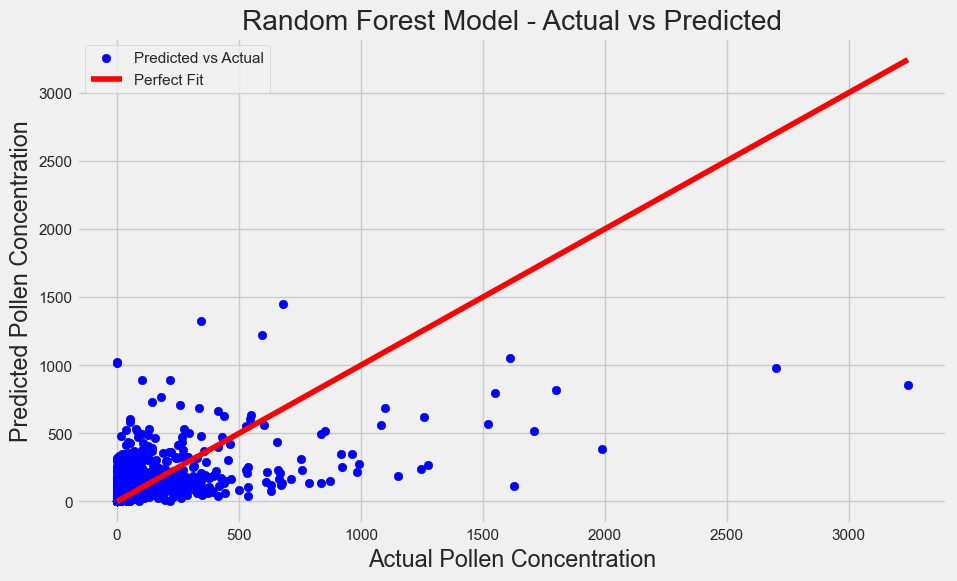

In [110]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Fit')
plt.xlabel('Actual Pollen Concentration')
plt.ylabel('Predicted Pollen Concentration')
plt.title('Random Forest Model - Actual vs Predicted')
plt.legend()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Load the dataset
data_path = 'C:/Users/Dell/Downloads/pollen_luxembourg_Dataset.csv'
pollen_data = pd.read_csv(data_path)

# Selecting a target pollen type, e.g., 'Ambrosia'
target_pollen = 'Ambrosia'

# Drop the 'Date' column for processing
pollen_data = pollen_data.drop(columns=['Date'])

# Normalize the data
scaler = MinMaxScaler()
pollen_data_scaled = scaler.fit_transform(pollen_data)

# Generate time series sequences
sequence_length = 7  # Use the last 7 days to predict the next day
generator = TimeseriesGenerator(pollen_data_scaled, pollen_data_scaled[:, pollen_data.columns.get_loc(target_pollen)],
                                length=sequence_length, batch_size=1)

# Building the model
model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(sequence_length, pollen_data_scaled.shape[1])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Fit the model
history = model.fit(generator, epochs=20, verbose=1)

# To make predictions (using the same generator for simplicity; ideally, you should use a separate test set)
predictions = model.predict(generator)

# To reverse the scaling to get interpretable results:
predictions_original = scaler.inverse_transform(np.c_[np.zeros((predictions.shape[0], pollen_data_scaled.shape[1]-1)), predictions])

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
  36/7777 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0013   

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7777/7777 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - loss: 7.9589e-04
Epoch 2/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 2.6883e-04
Epoch 3/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 5.1694e-04
Epoch 4/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.2278e-04
Epoch 5/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 3.8608e-04
Epoch 6/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 5.1051e-04
Epoch 7/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 4.2794e-04
Epoch 8/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 3.9343e-04
Epoch 9/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 3.0743e-04
Epoch 10/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 6.6984e-04
Epoch 11/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 3.2722e-04
Epoch 12/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 3.1292e-04
Epoch 13/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 4.7387e-04
Epoch 14/20
7777/7777 ━━━━━━━━━━━━━━━━━━━━ 11

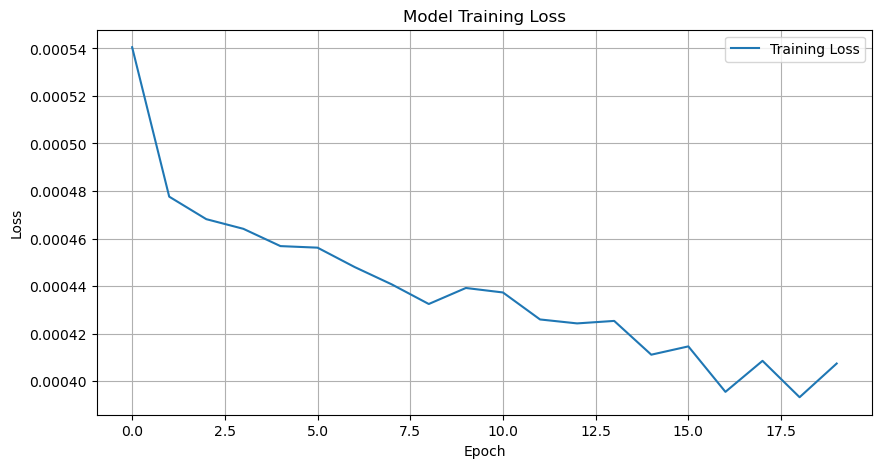

In [5]:
import matplotlib.pyplot as plt

# Plotting training loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [112]:
threshold = np.percentile(y_train, 90)
print(f"High Pollen Concentration Threshold: {threshold}")

High Pollen Concentration Threshold: 242.0


In [114]:
# Function to predict pollen concentration based on new weather data
def predict_pollen_concentration(weather_data):
    # weather_data should be a list or array with the same features as X
    prediction = rf_model.predict([weather_data])

    # Check if the predicted concentration exceeds the alert threshold
    if prediction > threshold:
        alert = "High Pollen Alert! Predicted Pollen Concentration exceeds the threshold."
    else:
        alert = "Pollen levels are within normal range."

    return prediction[0], alert

# Example input: New weather data [MaxAirTempC, MinAirTempC, PrecipitationC, Month, DayOfYear]
new_weather_data = [25, 15, 2.0, 6, 170]  # Example input (adjust this based on actual data)

# Get the prediction and alert
predicted_concentration, alert_message = predict_pollen_concentration(new_weather_data)

print(f"Predicted Pollen Concentration: {predicted_concentration}")
print(alert_message)

Predicted Pollen Concentration: 263.99
High Pollen Alert! Predicted Pollen Concentration exceeds the threshold.


In [116]:
# Function to get user input and make predictions
def get_user_input():
    MaxAirTempC = float(input("Enter Max Air Temperature (°C): "))
    MinAirTempC = float(input("Enter Min Air Temperature (°C): "))
    PrecipitationC = float(input("Enter Precipitation (mm): "))
    Month = int(input("Enter Month (1-12): "))
    DayOfYear = int(input("Enter Day of Year (1-365): "))

    return [MaxAirTempC, MinAirTempC, PrecipitationC, Month, DayOfYear]

# Use the Random Forest model to predict pollen concentration
def predict_and_alert():
    # Get user input
    new_weather_data = get_user_input()

    # Make prediction using the trained model
    predicted_concentration, alert_message = predict_pollen_concentration(new_weather_data)

    # Display prediction and alert
    print(f"\nPredicted Pollen Concentration: {predicted_concentration}")
    print(alert_message)


# Run the prediction and alert system
predict_and_alert()


Enter Max Air Temperature (°C):  36
Enter Min Air Temperature (°C):  18
Enter Precipitation (mm):  110
Enter Month (1-12):  09
Enter Day of Year (1-365):  196



Predicted Pollen Concentration: 203.63
Pollen levels are within normal range.


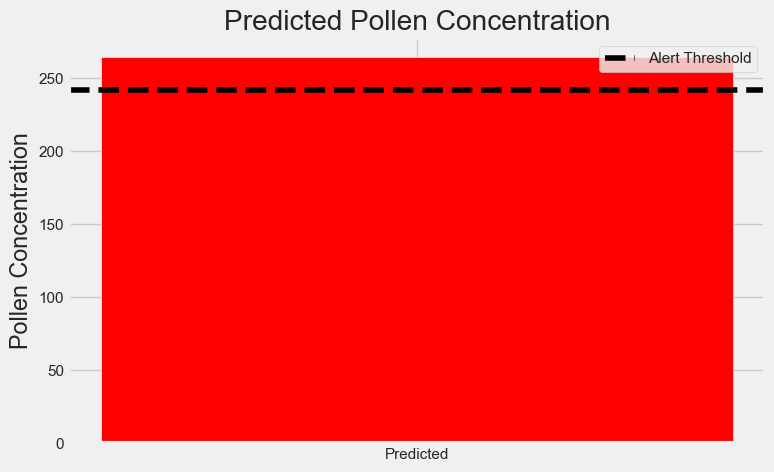

In [118]:
import matplotlib.pyplot as plt

# Bar chart showing predicted concentration
plt.bar(['Predicted'], [predicted_concentration], color='red' if predicted_concentration > threshold else 'green')
plt.axhline(y=threshold, color='black', linestyle='--', label='Alert Threshold')
plt.title('Predicted Pollen Concentration')
plt.ylabel('Pollen Concentration')
plt.legend()
plt.show()